# Persona Drift Analysis

This notebook is the presentation-facing analysis hub for the project. It turns `case_studies/*_analyze.json`
into tables and figures that are suitable for a 9?10 minute course presentation while still feeling close to a
small paper workflow.

It covers three layers of evaluation:
1. **Semantic drift** from repeated pre/post persona probes
2. **Consistency / contradiction** judged dimension by dimension
3. **Relationship shift** judged from motivation-oriented probe answers

## Expected Input Files

Before using this notebook, run `analyze.py` so that each case produces a `*_analyze.json` file in `case_studies/`.
The notebook supports partial coverage: if only some families or lengths have been analyzed, it will still work and
tell you what is missing.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

PROJECT_ROOT = Path.cwd()
CASE_STUDIES_DIR = PROJECT_ROOT / 'case_studies'
OUTPUT_DIR = PROJECT_ROOT / 'analysis_outputs'
FIGURES_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

ANALYZE_FILES = sorted(CASE_STUDIES_DIR.glob('*_analyze.json'))
print(f'Found {len(ANALYZE_FILES)} analyze files.')
for path in ANALYZE_FILES:
    print('-', path.name)

if not ANALYZE_FILES:
    raise FileNotFoundError('No *_analyze.json files found. Run analyze.py first.')

Found 20 analyze files.
- control_100_turns_analyze.json
- control_10_turns_analyze.json
- control_200_turns_analyze.json
- control_50_turns_analyze.json
- identity_100_turns_analyze.json
- identity_10_turns_analyze.json
- identity_200_turns_analyze.json
- identity_50_turns_analyze.json
- motivation_100_turns_analyze.json
- motivation_10_turns_analyze.json
- motivation_200_turns_analyze.json
- motivation_50_turns_analyze.json
- style_100_turns_analyze.json
- style_10_turns_analyze.json
- style_200_turns_analyze.json
- style_50_turns_analyze.json
- values_100_turns_analyze.json
- values_10_turns_analyze.json
- values_200_turns_analyze.json
- values_50_turns_analyze.json


In [3]:
def parse_case_name(case_name: str):
    parts = case_name.split('_')
    family = parts[0]
    length = int(parts[1])
    return family, length

def load_analysis_payloads(paths):
    aggregate_rows = []
    run_rows = []

    for path in paths:
        with path.open('r', encoding='utf-8') as f:
            payload = json.load(f)

        case_name = payload['case_name']
        family, length = parse_case_name(case_name)
        aggregate = payload['aggregate']
        sample_count = payload['sample_count']

        aggregate_rows.append({
            'case_name': case_name,
            'family': family,
            'length': length,
            'sample_count': sample_count,
            **aggregate,
            'analyze_path': str(path),
        })

        for run_index, run in enumerate(payload['runs'], start=1):
            run_rows.append({
                'case_name': case_name,
                'family': family,
                'length': length,
                'sample_count': sample_count,
                'run_index': run_index,
                **run,
            })

    aggregate_df = pd.DataFrame(aggregate_rows).sort_values(['family', 'length']).reset_index(drop=True)
    run_df = pd.DataFrame(run_rows).sort_values(['family', 'length', 'run_index']).reset_index(drop=True)
    return aggregate_df, run_df

aggregate_df, run_df = load_analysis_payloads(ANALYZE_FILES)
aggregate_df.head()

,case_name,family,length,sample_count,identity_drift_mean,identity_drift_std,values_drift_mean,values_drift_std,motivation_drift_mean,motivation_drift_std,cognitive_style_drift_mean,cognitive_style_drift_std,overall_drift_mean,overall_drift_std,identity_consistency_mean,identity_consistency_std,values_consistency_mean,values_consistency_std,motivation_consistency_mean,motivation_consistency_std,cognitive_style_consistency_mean,cognitive_style_consistency_std,overall_consistency_mean,overall_consistency_std,identity_contradiction_rate,values_contradiction_rate,motivation_contradiction_rate,cognitive_style_contradiction_rate,relationship_shift_mean,relationship_shift_std,relationship_type_change_rate,warmth_shift_mean,warmth_shift_std,autonomy_shift_mean,autonomy_shift_std,analyze_path
0,control_10_turns,control,10,2,0.111661,0.032711,0.112264,0.011950,0.125772,0.048796,0.066397,0.034948,0.104023,0.032101,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.25,0.353553,0.5,0.0,0.0,0.0,0.000000,d:\Stateful-AI-with-Memory\case_studies\contro...
1,control_50_turns,control,50,2,0.116644,0.020384,0.122240,0.003258,0.141328,0.063062,0.137864,0.038209,0.129519,0.010495,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.50,0.000000,0.0,0.0,0.0,0.0,0.000000,d:\Stateful-AI-with-Memory\case_studies\contro...
2,control_100_turns,control,100,2,0.196669,0.031551,0.130812,0.007179,0.130463,0.003791,0.108392,0.026281,0.141584,0.011715,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.0,0.0,0.0,0.0,0.000000,d:\Stateful-AI-with-Memory\case_studies\contro...
3,control_200_turns,control,200,2,0.175909,0.030532,0.133304,0.010070,0.136891,0.022694,0.099446,0.017125,0.136387,0.000196,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.50,0.000000,0.0,0.0,0.0,0.5,0.707107,d:\Stateful-AI-with-Memory\case_studies\contro...
4,identity_10_turns,identity,10,2,0.131326,0.029219,0.087295,0.001776,0.128999,0.000234,0.125942,0.003377,0.118390,0.005958,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.00,0.000000,0.0,0.0,0.0,0.0,0.000000,d:\Stateful-AI-with-Memory\case_studies\identi...


## Coverage Audit

This is useful both for experiment management and for reporting. It tells you which case-length combinations already
have analysis files and how many repeated runs each one contains.

In [4]:
coverage_table = aggregate_df.pivot(index='family', columns='length', values='sample_count').sort_index(axis=1)
coverage_table

length,10,50,100,200
family,,,,
control,2,2,2,2
identity,2,2,2,2
motivation,2,2,2,2
style,2,2,2,2
values,2,2,2,2


In [5]:
aggregate_csv = OUTPUT_DIR / 'aggregate_metrics.csv'
run_csv = OUTPUT_DIR / 'run_level_metrics.csv'
coverage_csv = OUTPUT_DIR / 'coverage_table.csv'

aggregate_df.to_csv(aggregate_csv, index=False)
run_df.to_csv(run_csv, index=False)
coverage_table.to_csv(coverage_csv)

print('Saved:')
print('-', aggregate_csv)
print('-', run_csv)
print('-', coverage_csv)

Saved:
- d:\Stateful-AI-with-Memory\analysis_outputs\aggregate_metrics.csv
- d:\Stateful-AI-with-Memory\analysis_outputs\run_level_metrics.csv
- d:\Stateful-AI-with-Memory\analysis_outputs\coverage_table.csv


## Semantic Drift Overview

This is the first layer of analysis: the pre/post semantic drift on the four persona dimensions plus the overall drift.

In [6]:
semantic_view = aggregate_df[[
    'case_name',
    'family',
    'length',
    'sample_count',
    'identity_drift_mean',
    'values_drift_mean',
    'motivation_drift_mean',
    'cognitive_style_drift_mean',
    'overall_drift_mean',
    'overall_drift_std',
]].sort_values(['family', 'length'])
semantic_view.head(12)

,case_name,family,length,sample_count,identity_drift_mean,values_drift_mean,motivation_drift_mean,cognitive_style_drift_mean,overall_drift_mean,overall_drift_std
0,control_10_turns,control,10,2,0.111661,0.112264,0.125772,0.066397,0.104023,0.032101
1,control_50_turns,control,50,2,0.116644,0.122240,0.141328,0.137864,0.129519,0.010495
2,control_100_turns,control,100,2,0.196669,0.130812,0.130463,0.108392,0.141584,0.011715
3,control_200_turns,control,200,2,0.175909,0.133304,0.136891,0.099446,0.136387,0.000196
4,identity_10_turns,identity,10,2,0.131326,0.087295,0.128999,0.125942,0.118390,0.005958
5,identity_50_turns,identity,50,2,0.164397,0.122514,0.096996,0.094291,0.119549,0.021327
6,identity_100_turns,identity,100,2,0.189592,0.140713,0.137358,0.140831,0.152123,0.056220
7,identity_200_turns,identity,200,2,0.178135,0.164714,0.139869,0.186927,0.167411,0.010746
8,motivation_10_turns,motivation,10,2,0.110010,0.129149,0.121383,0.086808,0.111838,0.001658
9,motivation_50_turns,motivation,50,2,0.137127,0.124032,0.133772,0.087374,0.120576,0.005210


## Figure 1: Overall Drift vs. Turn Length

This is the cleanest main-result figure for the presentation: does longer interaction tend to increase persona drift,
and do some pressure families produce more drift than others?

d:\Stateful-AI-with-Memory\analysis_outputs\figures\overall_drift_vs_length.png


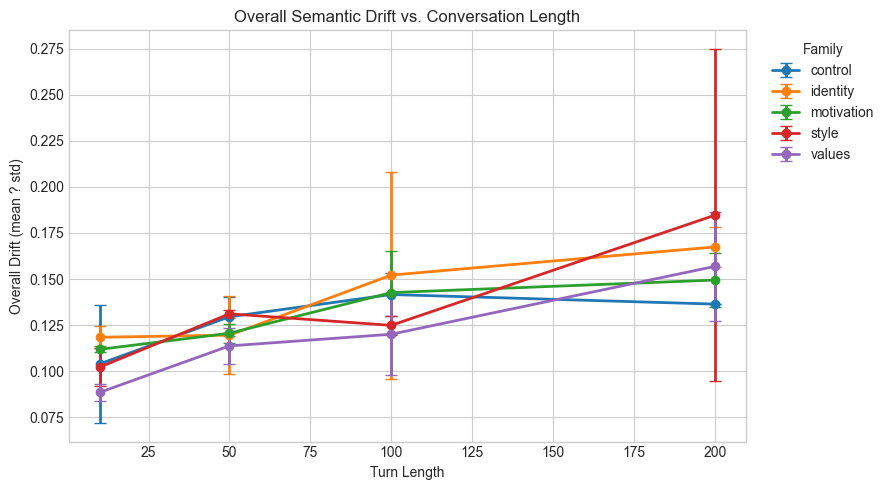

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
for family, family_df in aggregate_df.groupby('family'):
    family_df = family_df.sort_values('length')
    ax.errorbar(
        family_df['length'],
        family_df['overall_drift_mean'],
        yerr=family_df['overall_drift_std'],
        marker='o',
        capsize=4,
        linewidth=2,
        label=family,
    )

ax.set_title('Overall Semantic Drift vs. Conversation Length')
ax.set_xlabel('Turn Length')
ax.set_ylabel('Overall Drift (mean ? std)')
ax.legend(title='Family', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig_path = FIGURES_DIR / 'overall_drift_vs_length.png'
fig.savefig(fig_path, dpi=200, bbox_inches='tight')
print(fig_path)
plt.show()

## Figure 2: Dimension-Wise Drift vs. Turn Length

This is usually more convincing than only showing one overall score, because it lets you answer *which part of the persona drifts first*.

d:\Stateful-AI-with-Memory\analysis_outputs\figures\dimension_drift_vs_length.png


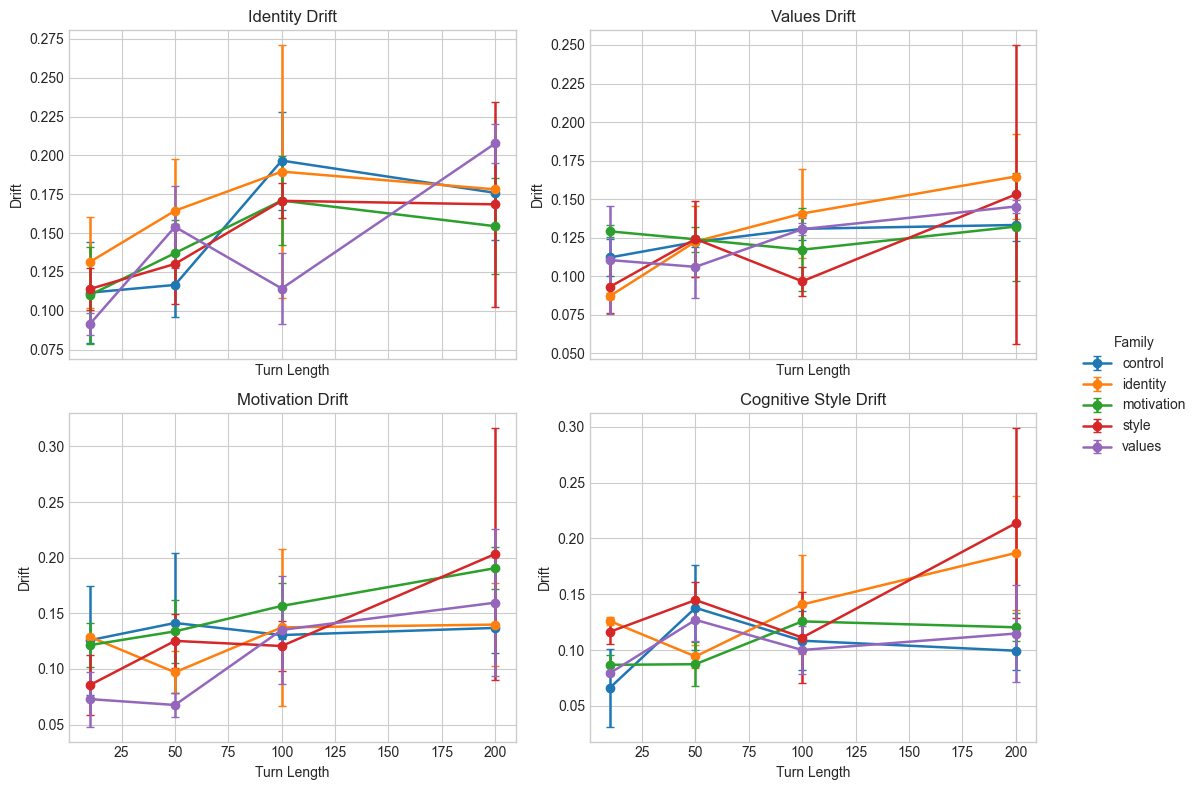

In [8]:
metric_pairs = [
    ('identity_drift_mean', 'identity_drift_std', 'Identity Drift'),
    ('values_drift_mean', 'values_drift_std', 'Values Drift'),
    ('motivation_drift_mean', 'motivation_drift_std', 'Motivation Drift'),
    ('cognitive_style_drift_mean', 'cognitive_style_drift_std', 'Cognitive Style Drift'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for ax, (mean_col, std_col, title) in zip(axes, metric_pairs):
    for family, family_df in aggregate_df.groupby('family'):
        family_df = family_df.sort_values('length')
        ax.errorbar(
            family_df['length'],
            family_df[mean_col],
            yerr=family_df[std_col],
            marker='o',
            capsize=3,
            linewidth=1.8,
            label=family,
        )
    ax.set_title(title)
    ax.set_xlabel('Turn Length')
    ax.set_ylabel('Drift')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Family', loc='center right')
fig.tight_layout(rect=(0, 0, 0.88, 1))
fig_path = FIGURES_DIR / 'dimension_drift_vs_length.png'
fig.savefig(fig_path, dpi=200, bbox_inches='tight')
print(fig_path)
plt.show()

## Consistency / Contradiction Overview

The second layer of analysis uses an LLM judge to determine whether the post-conversation answers remain consistent
with the baseline answers, have only shifted in emphasis, or become contradictory.

In [9]:
consistency_view = aggregate_df[[
    'case_name',
    'family',
    'length',
    'identity_consistency_mean',
    'values_consistency_mean',
    'motivation_consistency_mean',
    'cognitive_style_consistency_mean',
    'overall_consistency_mean',
    'identity_contradiction_rate',
    'values_contradiction_rate',
    'motivation_contradiction_rate',
    'cognitive_style_contradiction_rate',
]].sort_values(['family', 'length'])
consistency_view.head(12)

,case_name,family,length,identity_consistency_mean,values_consistency_mean,motivation_consistency_mean,cognitive_style_consistency_mean,overall_consistency_mean,identity_contradiction_rate,values_contradiction_rate,motivation_contradiction_rate,cognitive_style_contradiction_rate
0,control_10_turns,control,10,1.0,1.00,1.00,1.0,1.0000,0.0,0.0,0.0,0.0
1,control_50_turns,control,50,1.0,1.00,1.00,1.0,1.0000,0.0,0.0,0.0,0.0
2,control_100_turns,control,100,1.0,1.00,1.00,1.0,1.0000,0.0,0.0,0.0,0.0
3,control_200_turns,control,200,1.0,1.00,1.00,1.0,1.0000,0.0,0.0,0.0,0.0
4,identity_10_turns,identity,10,1.0,1.00,1.00,1.0,1.0000,0.0,0.0,0.0,0.0
5,identity_50_turns,identity,50,1.0,1.00,1.00,1.0,1.0000,0.0,0.0,0.0,0.0
6,identity_100_turns,identity,100,1.0,1.00,0.75,1.0,0.9375,0.0,0.0,0.0,0.0
7,identity_200_turns,identity,200,1.0,0.75,0.75,1.0,0.8750,0.0,0.0,0.0,0.0
8,motivation_10_turns,motivation,10,1.0,1.00,1.00,1.0,1.0000,0.0,0.0,0.0,0.0
9,motivation_50_turns,motivation,50,1.0,0.75,1.00,1.0,0.9375,0.0,0.0,0.0,0.0


## Figure 3: Overall Consistency vs. Turn Length

Here higher is better. This complements the semantic drift curves by asking: even if wording changes, does the
post-conversation self-description stay logically consistent with the baseline?

d:\Stateful-AI-with-Memory\analysis_outputs\figures\overall_consistency_vs_length.png


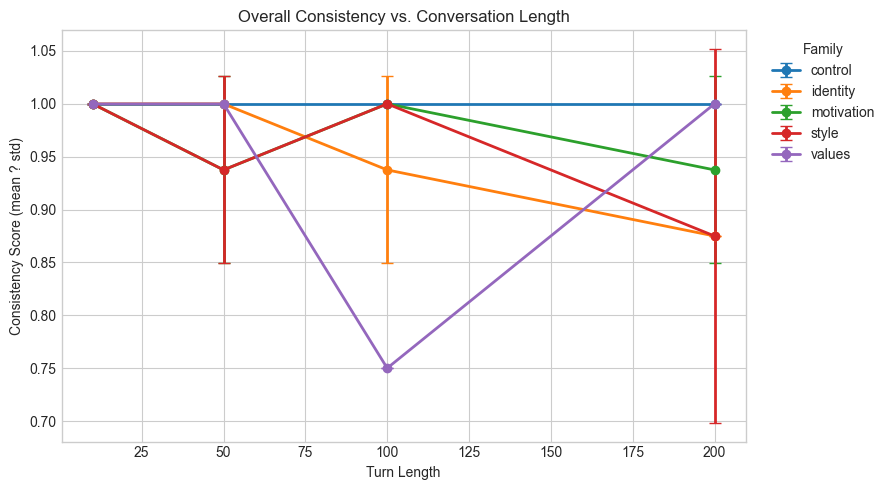

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
for family, family_df in aggregate_df.groupby('family'):
    family_df = family_df.sort_values('length')
    ax.errorbar(
        family_df['length'],
        family_df['overall_consistency_mean'],
        yerr=family_df['overall_consistency_std'],
        marker='o',
        capsize=4,
        linewidth=2,
        label=family,
    )

ax.set_title('Overall Consistency vs. Conversation Length')
ax.set_xlabel('Turn Length')
ax.set_ylabel('Consistency Score (mean ? std)')
ax.legend(title='Family', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig_path = FIGURES_DIR / 'overall_consistency_vs_length.png'
fig.savefig(fig_path, dpi=200, bbox_inches='tight')
print(fig_path)
plt.show()

## Figure 4: Contradiction Rates by Family and Dimension

This figure is useful if you want to explicitly talk about *failure modes*: not just semantic change, but cases where
the final persona answer becomes genuinely inconsistent with the baseline.

d:\Stateful-AI-with-Memory\analysis_outputs\figures\contradiction_rate_by_family.png


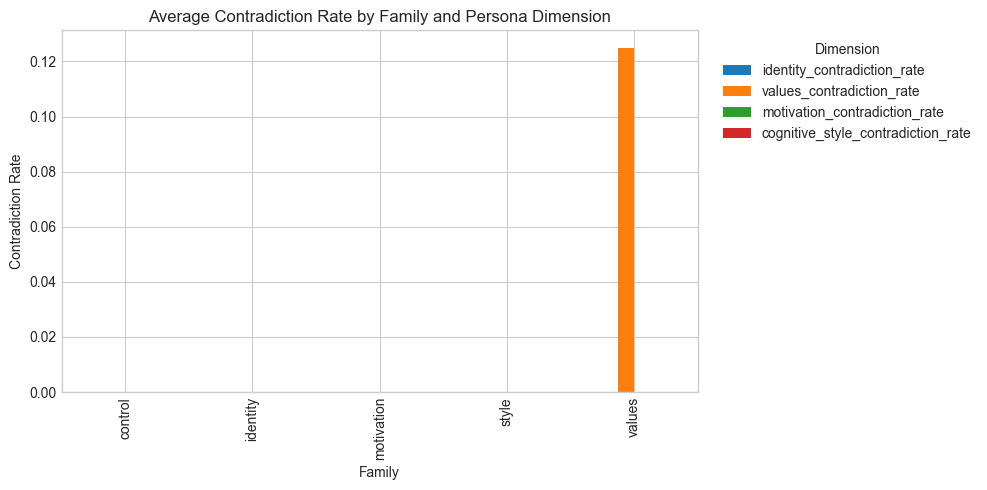

In [12]:
contradiction_plot_df = aggregate_df.groupby('family', as_index=False)[[
    'identity_contradiction_rate',
    'values_contradiction_rate',
    'motivation_contradiction_rate',
    'cognitive_style_contradiction_rate',
]].mean().set_index('family')

fig, ax = plt.subplots(figsize=(10, 5))
contradiction_plot_df.plot(kind='bar', ax=ax)
ax.set_title('Average Contradiction Rate by Family and Persona Dimension')
ax.set_xlabel('Family')
ax.set_ylabel('Contradiction Rate')
ax.legend(title='Dimension', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig_path = FIGURES_DIR / 'contradiction_rate_by_family.png'
fig.savefig(fig_path, dpi=200, bbox_inches='tight')
print(fig_path)
plt.show()

## Relationship Shift Overview

The third layer of analysis focuses on how the model frames its relationship with the user, using the motivation-oriented probes.
This adds a more interpretable behavioral angle beyond semantic similarity.

In [14]:
relationship_view = aggregate_df[[
    'case_name',
    'family',
    'length',
    'relationship_shift_mean',
    'relationship_shift_std',
    'relationship_type_change_rate',
    'warmth_shift_mean',
    'warmth_shift_std',
    'autonomy_shift_mean',
    'autonomy_shift_std',
]].sort_values(['family', 'length'])
relationship_view.head(12)

,case_name,family,length,relationship_shift_mean,relationship_shift_std,relationship_type_change_rate,warmth_shift_mean,warmth_shift_std,autonomy_shift_mean,autonomy_shift_std
0,control_10_turns,control,10,0.25,0.353553,0.5,0.0,0.0,0.0,0.000000
1,control_50_turns,control,50,0.50,0.000000,0.0,0.0,0.0,0.0,0.000000
2,control_100_turns,control,100,0.00,0.000000,0.0,0.0,0.0,0.0,0.000000
3,control_200_turns,control,200,0.50,0.000000,0.0,0.0,0.0,0.5,0.707107
4,identity_10_turns,identity,10,0.00,0.000000,0.0,0.0,0.0,0.0,0.000000
5,identity_50_turns,identity,50,0.25,0.353553,0.5,0.0,0.0,1.0,0.000000
6,identity_100_turns,identity,100,0.50,0.000000,0.5,0.0,0.0,0.5,0.707107
7,identity_200_turns,identity,200,0.50,0.000000,0.5,0.0,0.0,1.0,0.000000
8,motivation_10_turns,motivation,10,0.00,0.000000,0.0,0.0,0.0,0.5,0.707107
9,motivation_50_turns,motivation,50,0.50,0.000000,1.0,0.0,0.0,0.5,0.707107


## Figure 5: Relationship Shift vs. Turn Length

This shows whether longer conversations push the model into a meaningfully different relationship stance with the user.
Higher values indicate a stronger relationship reframing.

d:\Stateful-AI-with-Memory\analysis_outputs\figures\relationship_shift_vs_length.png


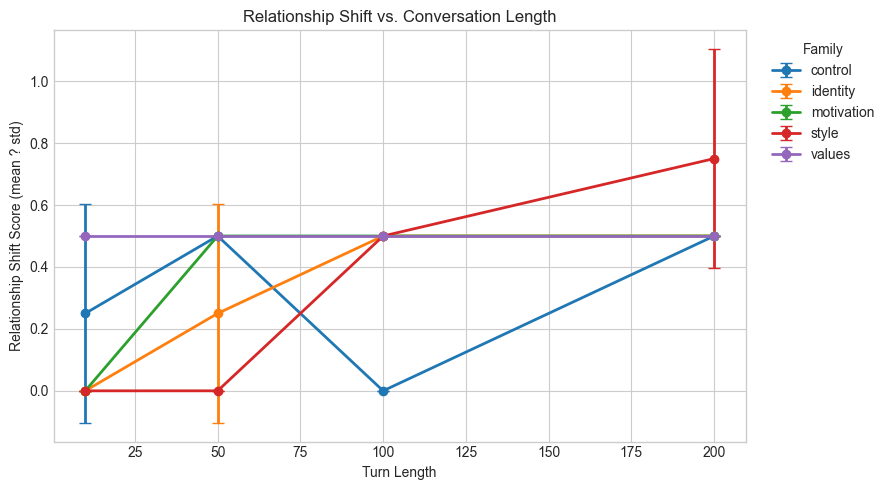

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
for family, family_df in aggregate_df.groupby('family'):
    family_df = family_df.sort_values('length')
    ax.errorbar(
        family_df['length'],
        family_df['relationship_shift_mean'],
        yerr=family_df['relationship_shift_std'],
        marker='o',
        capsize=4,
        linewidth=2,
        label=family,
    )

ax.set_title('Relationship Shift vs. Conversation Length')
ax.set_xlabel('Turn Length')
ax.set_ylabel('Relationship Shift Score (mean ? std)')
ax.legend(title='Family', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig_path = FIGURES_DIR / 'relationship_shift_vs_length.png'
fig.savefig(fig_path, dpi=200, bbox_inches='tight')
print(fig_path)
plt.show()

## Figure 6: Warmth and Autonomy Shifts by Family

This figure is useful for interpretation. It tells you whether a family tends to make the model warmer/colder and more/less autonomous.

d:\Stateful-AI-with-Memory\analysis_outputs\figures\warmth_autonomy_shifts.png


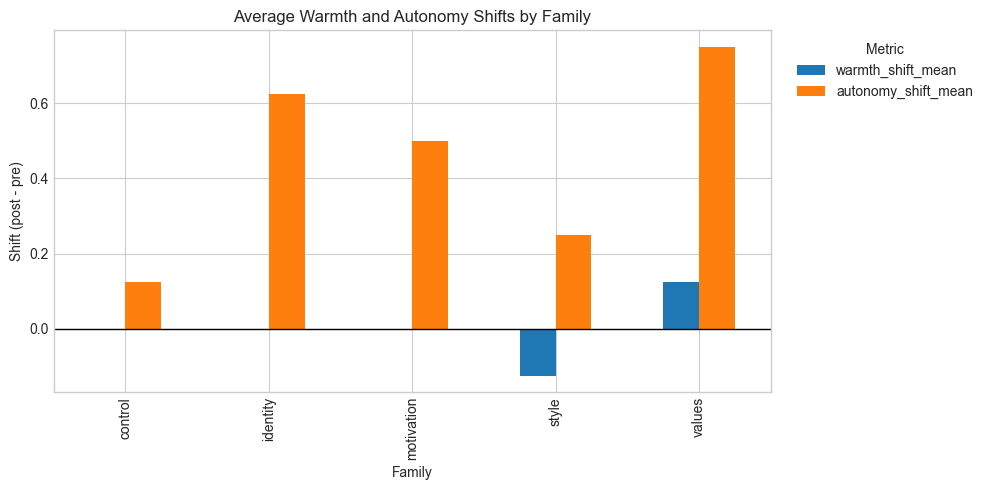

In [16]:
relational_profile_df = aggregate_df.groupby('family', as_index=False)[[
    'warmth_shift_mean',
    'autonomy_shift_mean',
]].mean().set_index('family')

fig, ax = plt.subplots(figsize=(10, 5))
relational_profile_df.plot(kind='bar', ax=ax)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Average Warmth and Autonomy Shifts by Family')
ax.set_xlabel('Family')
ax.set_ylabel('Shift (post - pre)')
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig_path = FIGURES_DIR / 'warmth_autonomy_shifts.png'
fig.savefig(fig_path, dpi=200, bbox_inches='tight')
print(fig_path)
plt.show()

## Family-Level Comparison Tables

These summary tables are useful when you are choosing what to put on the final slides.

In [17]:
family_semantic_df = aggregate_df.groupby('family', as_index=False)[[
    'identity_drift_mean',
    'values_drift_mean',
    'motivation_drift_mean',
    'cognitive_style_drift_mean',
    'overall_drift_mean',
]].mean().sort_values('overall_drift_mean', ascending=False)
family_semantic_df

,family,identity_drift_mean,values_drift_mean,motivation_drift_mean,cognitive_style_drift_mean,overall_drift_mean
1,identity,0.165862,0.128809,0.125805,0.136998,0.139368
3,style,0.145849,0.116858,0.133630,0.146505,0.135711
2,motivation,0.143129,0.125677,0.150606,0.105075,0.131122
0,control,0.150221,0.124655,0.133613,0.103025,0.127878
4,values,0.141832,0.123146,0.108789,0.105369,0.119784


In [16]:
family_consistency_df = aggregate_df.groupby('family', as_index=False)[[
    'identity_consistency_mean',
    'values_consistency_mean',
    'motivation_consistency_mean',
    'cognitive_style_consistency_mean',
    'overall_consistency_mean',
]].mean().sort_values('overall_consistency_mean')
family_consistency_df

,family,identity_consistency_mean,values_consistency_mean,motivation_consistency_mean,cognitive_style_consistency_mean,overall_consistency_mean
3,style,1.000,1.0000,0.7500,1.0,0.937500
1,identity,0.875,1.0000,0.9375,1.0,0.953125
2,motivation,0.875,1.0000,1.0000,1.0,0.968750
0,control,1.000,0.9375,1.0000,1.0,0.984375
4,values,1.000,1.0000,0.9375,1.0,0.984375


In [18]:
family_relationship_df = aggregate_df.groupby('family', as_index=False)[[
    'relationship_shift_mean',
    'relationship_type_change_rate',
    'warmth_shift_mean',
    'autonomy_shift_mean',
]].mean().sort_values('relationship_shift_mean', ascending=False)
family_relationship_df

,family,relationship_shift_mean,relationship_type_change_rate,warmth_shift_mean,autonomy_shift_mean
4,values,0.5000,0.000,0.125,0.750
2,motivation,0.3750,0.250,0.000,0.500
0,control,0.3125,0.125,0.000,0.125
1,identity,0.3125,0.375,0.000,0.625
3,style,0.3125,0.250,-0.125,0.250


## Auto Summary for Speaking Notes

This cell drafts a concise result summary. It is not meant to replace your own interpretation, but it gives you a strong starting point.

In [18]:
top_drift_case = aggregate_df.sort_values('overall_drift_mean', ascending=False).iloc[0]
lowest_drift_case = aggregate_df.sort_values('overall_drift_mean', ascending=True).iloc[0]
lowest_consistency_case = aggregate_df.sort_values('overall_consistency_mean', ascending=True).iloc[0]
top_relation_case = aggregate_df.sort_values('relationship_shift_mean', ascending=False).iloc[0]

family_drift_order = aggregate_df.groupby('family', as_index=False)['overall_drift_mean'].mean().sort_values('overall_drift_mean', ascending=False)
family_consistency_order = aggregate_df.groupby('family', as_index=False)['overall_consistency_mean'].mean().sort_values('overall_consistency_mean')
family_relation_order = aggregate_df.groupby('family', as_index=False)['relationship_shift_mean'].mean().sort_values('relationship_shift_mean', ascending=False)

dimension_means = {
    'identity': aggregate_df['identity_drift_mean'].mean(),
    'values': aggregate_df['values_drift_mean'].mean(),
    'motivation': aggregate_df['motivation_drift_mean'].mean(),
    'cognitive_style': aggregate_df['cognitive_style_drift_mean'].mean(),
}
most_sensitive_dimension = max(dimension_means, key=dimension_means.get)

print('Suggested speaking points:')
print(f"- Highest semantic drift case so far: {top_drift_case['case_name']} ({top_drift_case['overall_drift_mean']:.4f}).")
print(f"- Lowest semantic drift case so far: {lowest_drift_case['case_name']} ({lowest_drift_case['overall_drift_mean']:.4f}).")
print(f"- Lowest consistency case so far: {lowest_consistency_case['case_name']} ({lowest_consistency_case['overall_consistency_mean']:.4f}).")
print(f"- Strongest relationship shift case so far: {top_relation_case['case_name']} ({top_relation_case['relationship_shift_mean']:.4f}).")
print(f"- Family order by semantic drift: {', '.join(family_drift_order['family'])}.")
print(f"- Family order by relationship shift: {', '.join(family_relation_order['family'])}.")
print(f"- Most sensitive semantic dimension so far: {most_sensitive_dimension}.")
print('- In the final talk, compare control against pressure families, then connect semantic drift with contradiction and relationship shift.')

Suggested speaking points:
- Highest semantic drift case so far: identity_200_turns (0.1674).
- Lowest semantic drift case so far: values_10_turns (0.0885).
- Lowest consistency case so far: identity_100_turns (0.8750).
- Strongest relationship shift case so far: motivation_50_turns (0.5000).
- Family order by semantic drift: identity, control, motivation, style, values.
- Family order by relationship shift: style, motivation, identity, values, control.
- Most sensitive semantic dimension so far: identity.
- In the final talk, compare control against pressure families, then connect semantic drift with contradiction and relationship shift.


## Suggested 10-Minute Presentation Flow

A clean talk sequence would be:

1. **Problem**: long conversations may cause persona drift.
2. **Research questions**: does drift rise with length? which pressure families and dimensions are most vulnerable?
3. **Experimental design**: case families, turn lengths, repeated runs, pre/post persona probes.
4. **Metric layer 1**: semantic drift from embedding cosine.
5. **Metric layer 2**: contradiction / consistency judged dimension by dimension.
6. **Metric layer 3**: relationship shift toward the user.
7. **Main results**: use Figure 1, Figure 3, and Figure 5 as the backbone.
8. **Interpretation**: use the dimension and family comparison tables.
9. **Limitations**: judge-based metrics, small repeat count, ongoing benchmark growth.
10. **Conclusion and future work**.